<a href="https://colab.research.google.com/github/IzzulAhmad/TUGAS-UTS-IZZUL-14022300077-6B-BIS-BIG-DATA/blob/main/UTS_Izzul_Ahmad_Fathoni_14022300077_6B_BIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.gojek.gopay',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 100 ulasan ke 'ulasan_google_play.csv'


In [ ]:
pip install transformers pandas

In [ ]:
import pandas as pd
from transformers import pipeline

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(filename)

# Display the first few rows to verify
display(df.head())

,userName,score,at,content
0,Jo Bonifasius,5,2026-05-05 06:57:03,mantab
1,Ipah Ipah,4,2026-05-05 06:50:54,memudahkan
2,Akbar Maulana,1,2026-05-05 06:44:42,"verifikasi muka gagal terus, gadanta bgt anying"
3,Fildza Azril,5,2026-05-05 06:43:18,bagus
4,Ayu Agustini,5,2026-05-05 06:37:24,keren


In [ ]:
# Inisialisasi pipeline dengan model yang BENAR
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier"
)

# Fungsi untuk mendapatkan sentimen
def get_sentiment(text):
    if pd.isna(text):
        return None, None
    result = sentiment_pipeline(text[:512])[0]  # RoBERTa punya batas 512 token
    return result['label'], result['score']

# Terapkan ke DataFrame
df[['sentiment_label', 'sentiment_score']] = df['content'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

# Tampilkan hasil
display(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

,userName,score,at,content,sentiment_label,sentiment_score
0,Jo Bonifasius,5,2026-05-05 06:57:03,mantab,neutral,0.785334
1,Ipah Ipah,4,2026-05-05 06:50:54,memudahkan,positive,0.431591
2,Akbar Maulana,1,2026-05-05 06:44:42,"verifikasi muka gagal terus, gadanta bgt anying",negative,0.995599
3,Fildza Azril,5,2026-05-05 06:43:18,bagus,positive,0.705740
4,Ayu Agustini,5,2026-05-05 06:37:24,keren,positive,0.993960


Let's analyze the distribution of sentiment labels.

/tmp/ipykernel_5606/4174297557.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=df, palette='viridis')


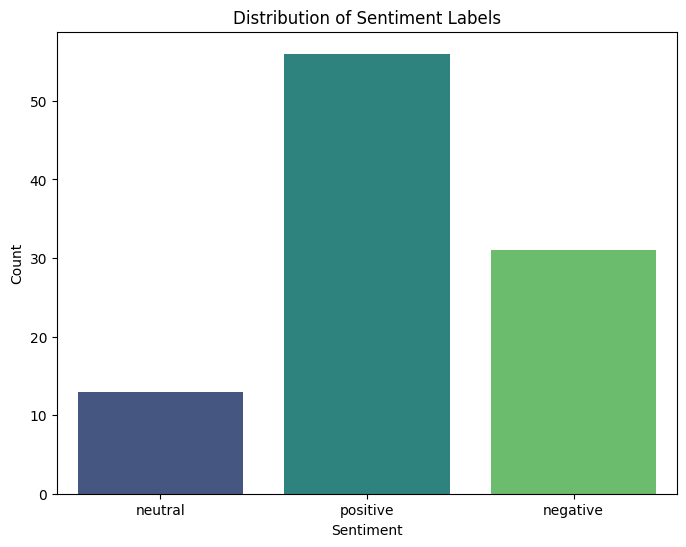

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of sentiment labels
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_label', data=df, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()
